### Этот ноутбук восстанавливает монетраное правило с 2014 года в России. Отсюда берутся структурные шоки для раздела 2.2

#### Данные

Это pandas DataFrame!


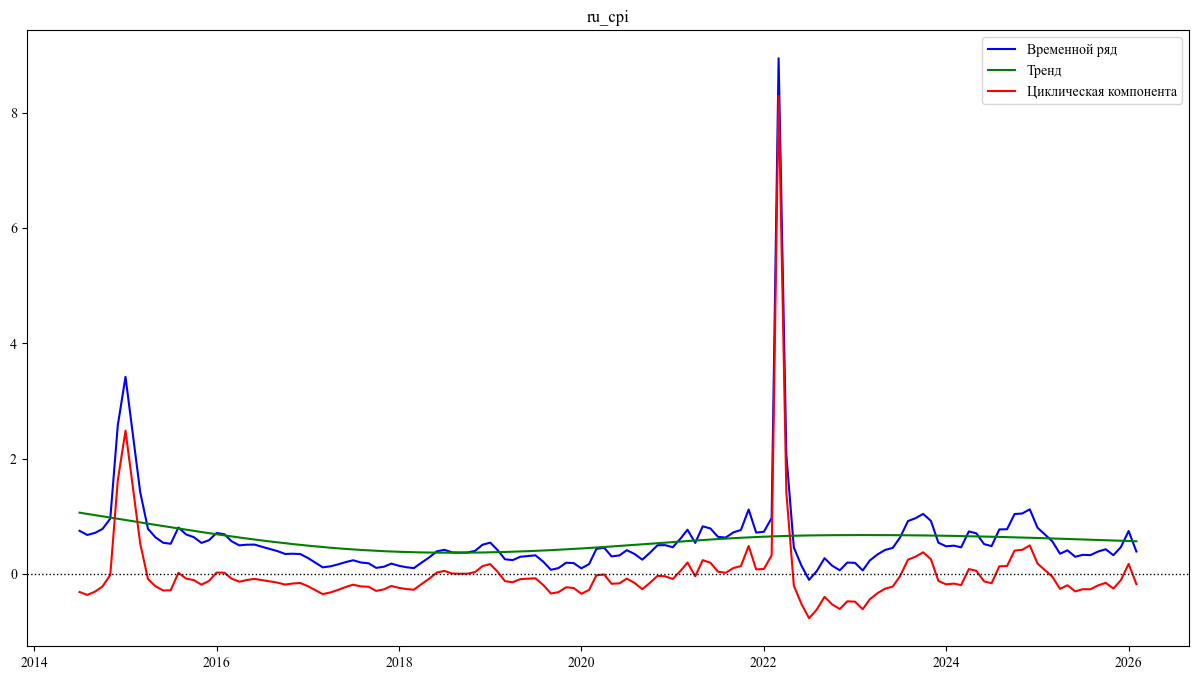

Исходный ряд ru_cpi оказался стационарным


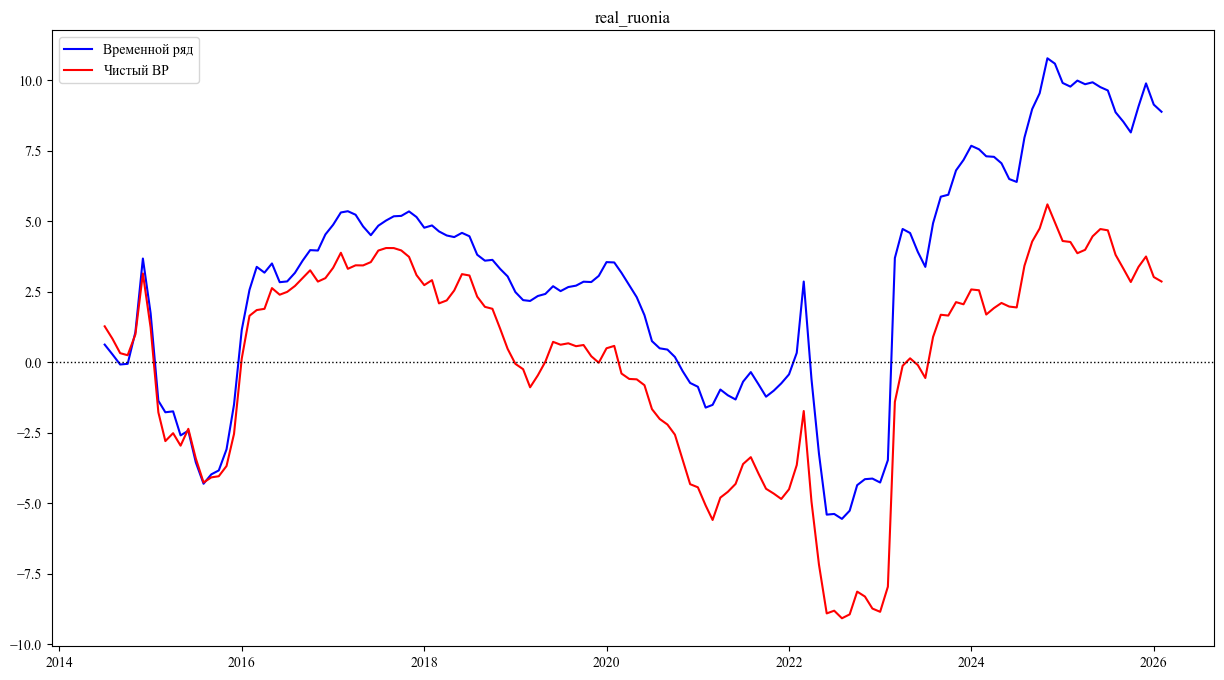

Исходный ряд real_ruonia оказался стационарным


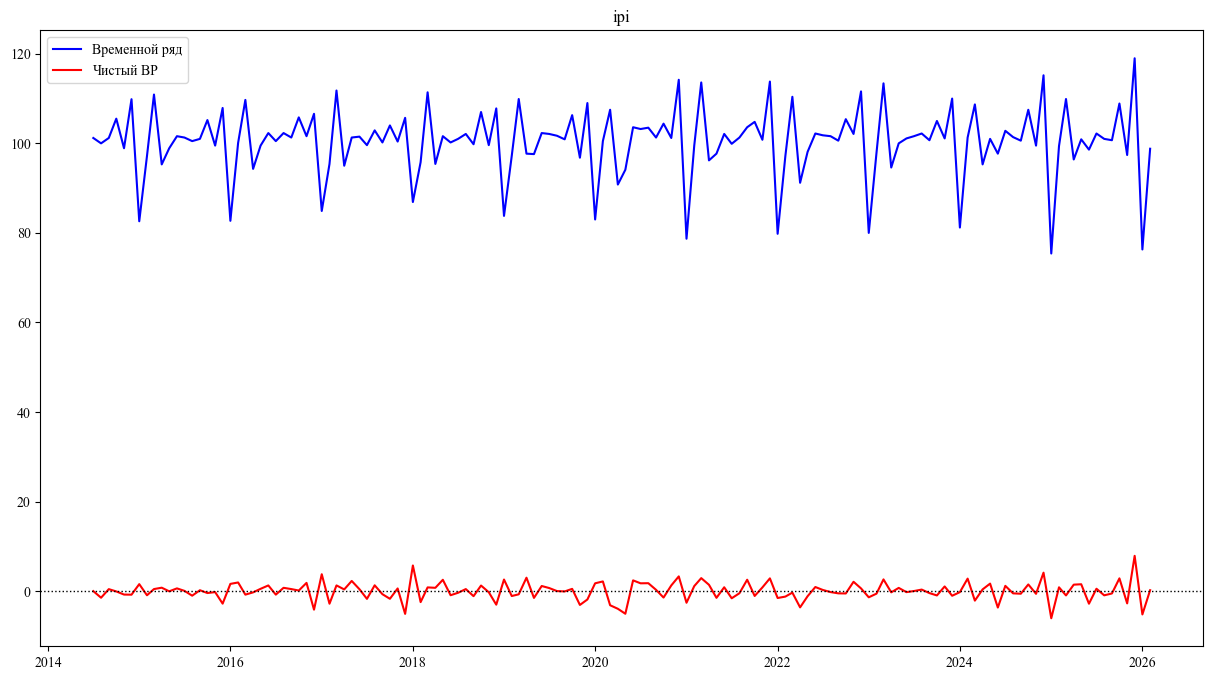

Исходный ряд ipi оказался стационарным


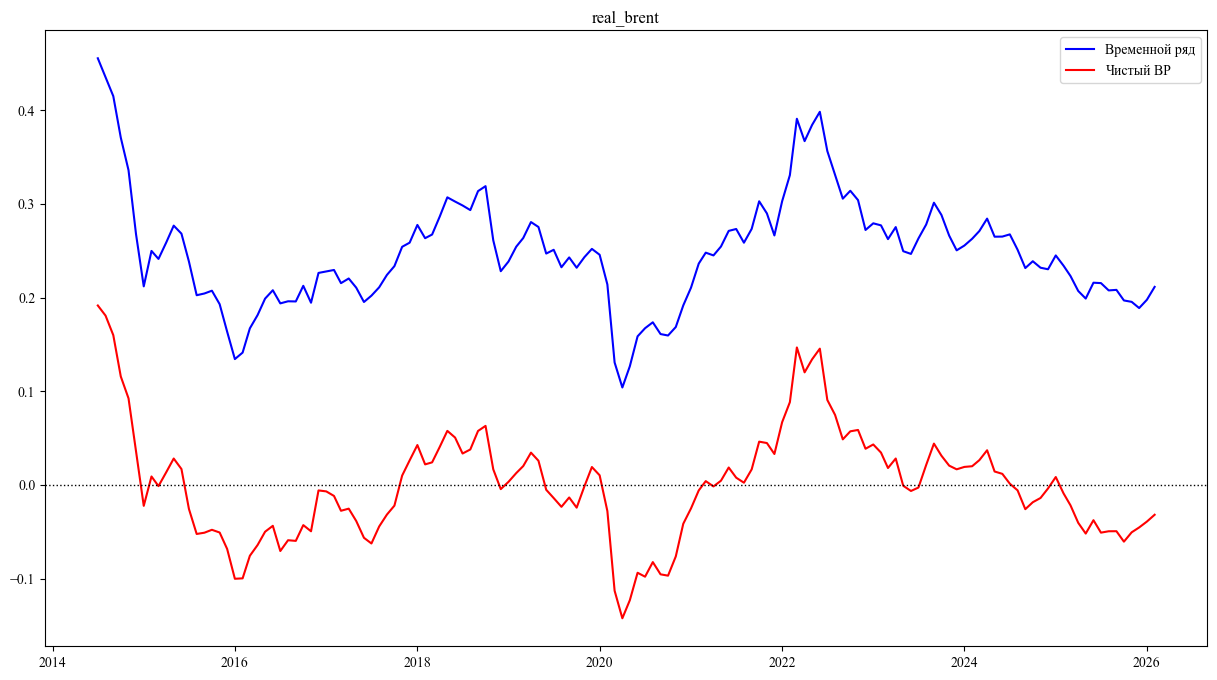

Исходный ряд real_brent оказался стационарным


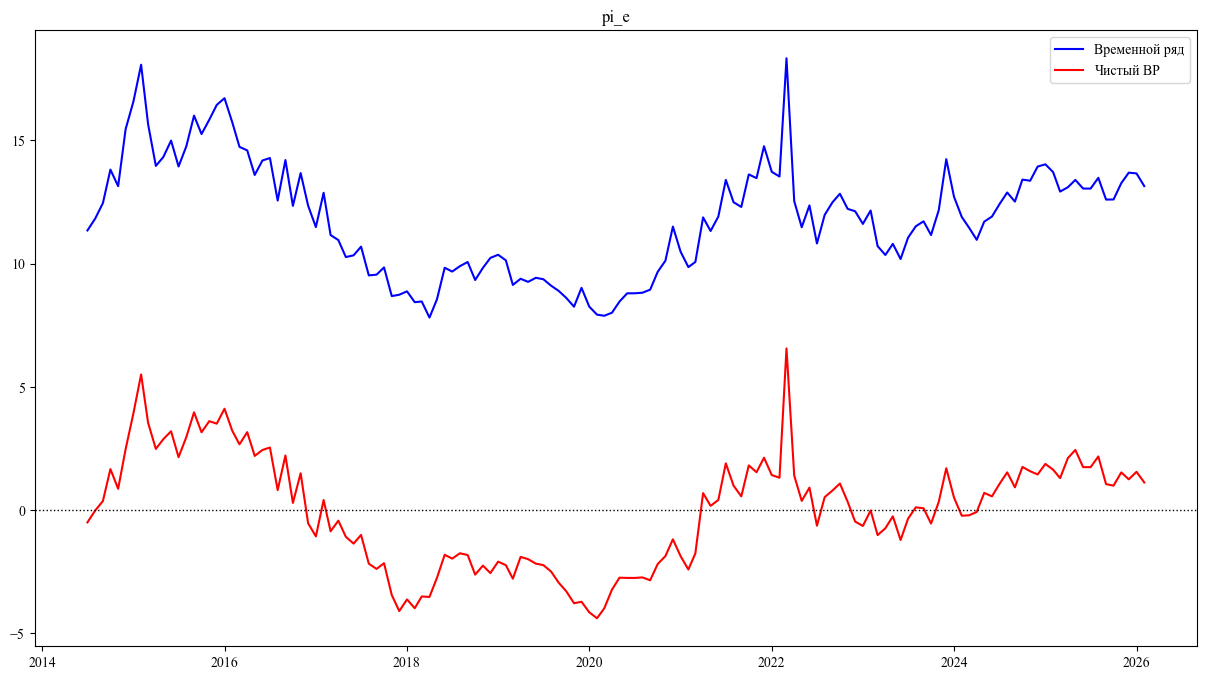

Исходный ряд pi_e оказался стационарным


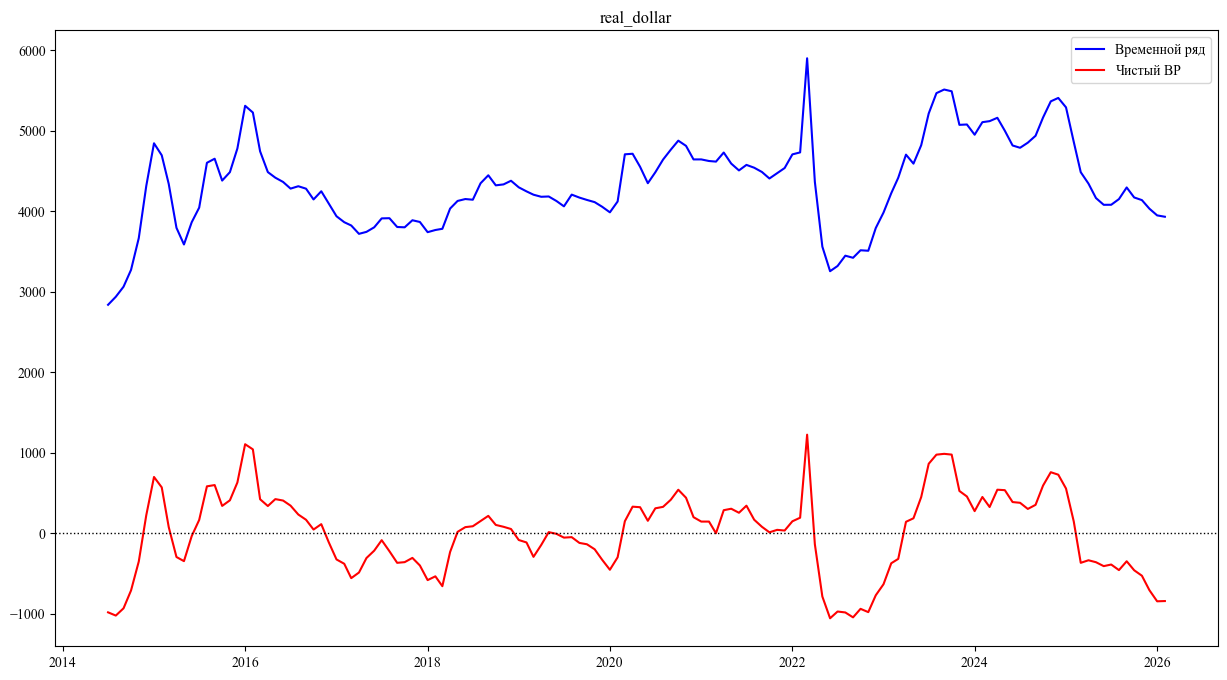

Исходный ряд real_dollar оказался стационарным


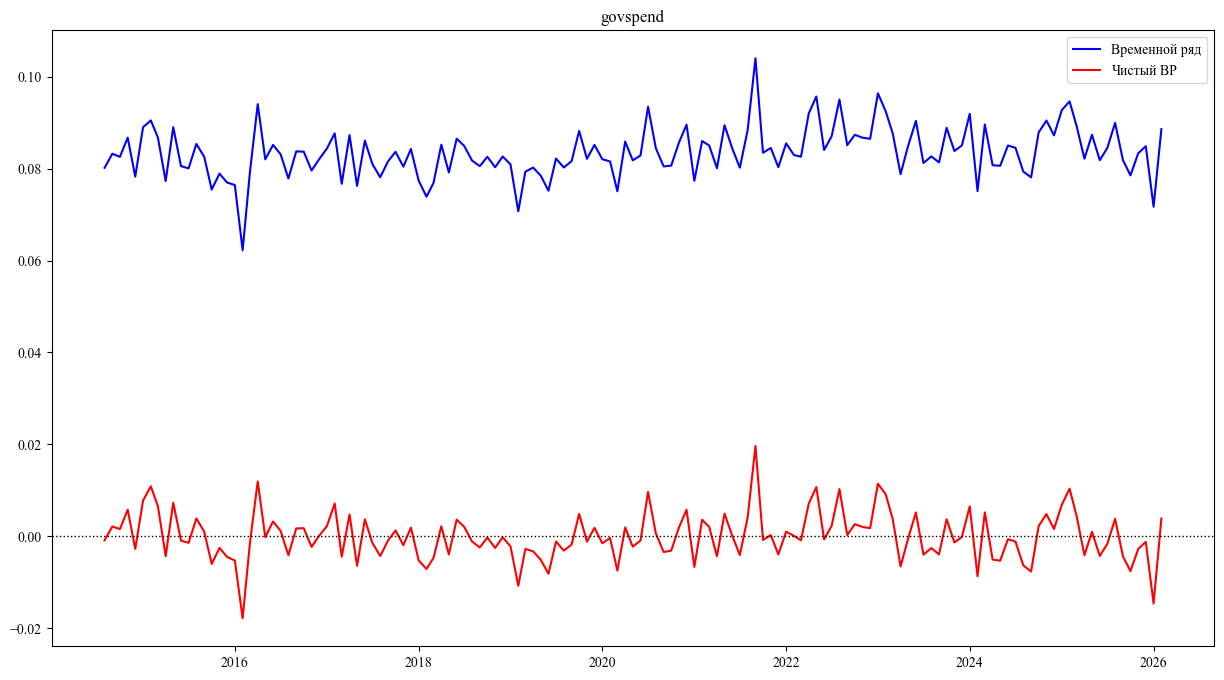

Исходный ряд govspend оказался стационарным


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt

import pickle

import warnings
warnings.filterwarnings("ignore", message="Workbook contains no default style.*")


filename = 'data/monthly_data.pkl'
with open(filename, 'rb') as f:
    monthly_data = pickle.load(f)

from structuralvar import Clean, SVAR_KL

var_spec = Clean(monthly_data.loc[(monthly_data.index > dt(2014, 6, 1)) & (monthly_data.index < dt(2026, 3, 1)),
                                   ['ru_cpi', 'real_ruonia', 'ipi',
                                    'real_brent', 'pi_e','real_dollar', 'govspend']])

df, data = var_spec.LOS(use_harmonics=False, only_KPSS = True, hp_filter_map={
    'ru_cpi': True,
    })

data.loc['govspend'] = data.loc['govspend'].copy()*10
covid_start, duration_covid = (data.T.index < dt(2020, 3, 1)).sum(), 5
svo_start, svo_duration = (data.T.index < dt(2022, 2, 1)).sum(), 2



#### Спецификация и правило монетарной политики

Это pandas DataFrame!


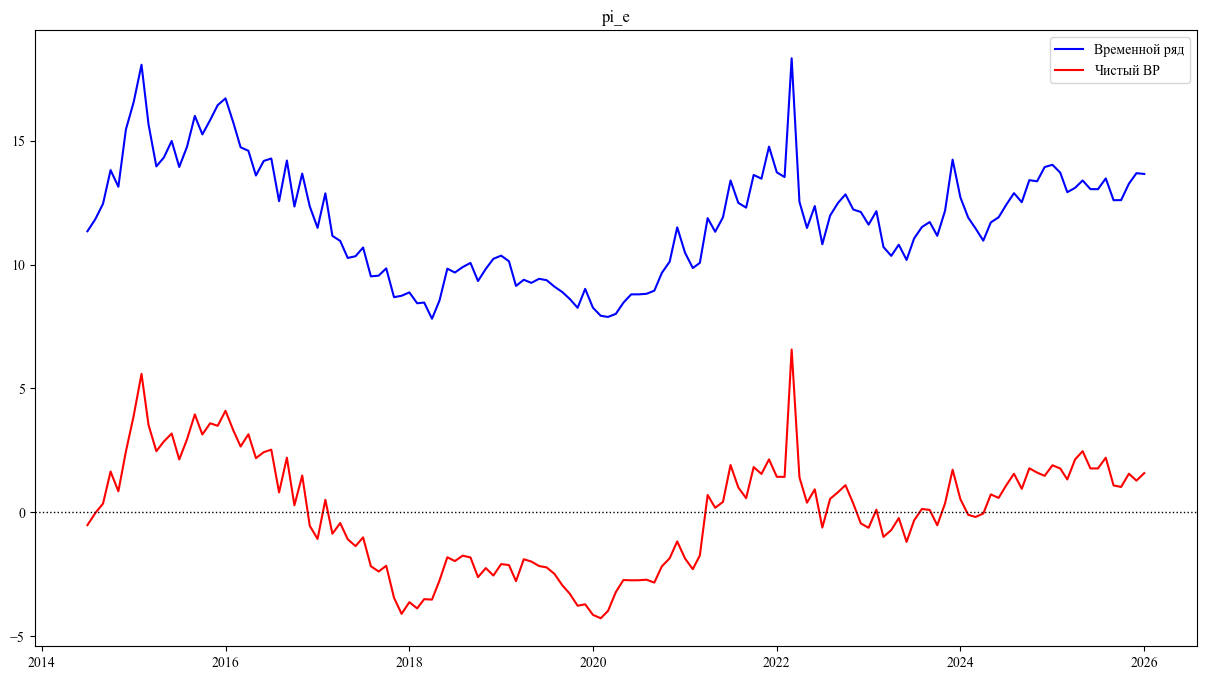

Исходный ряд pi_e оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


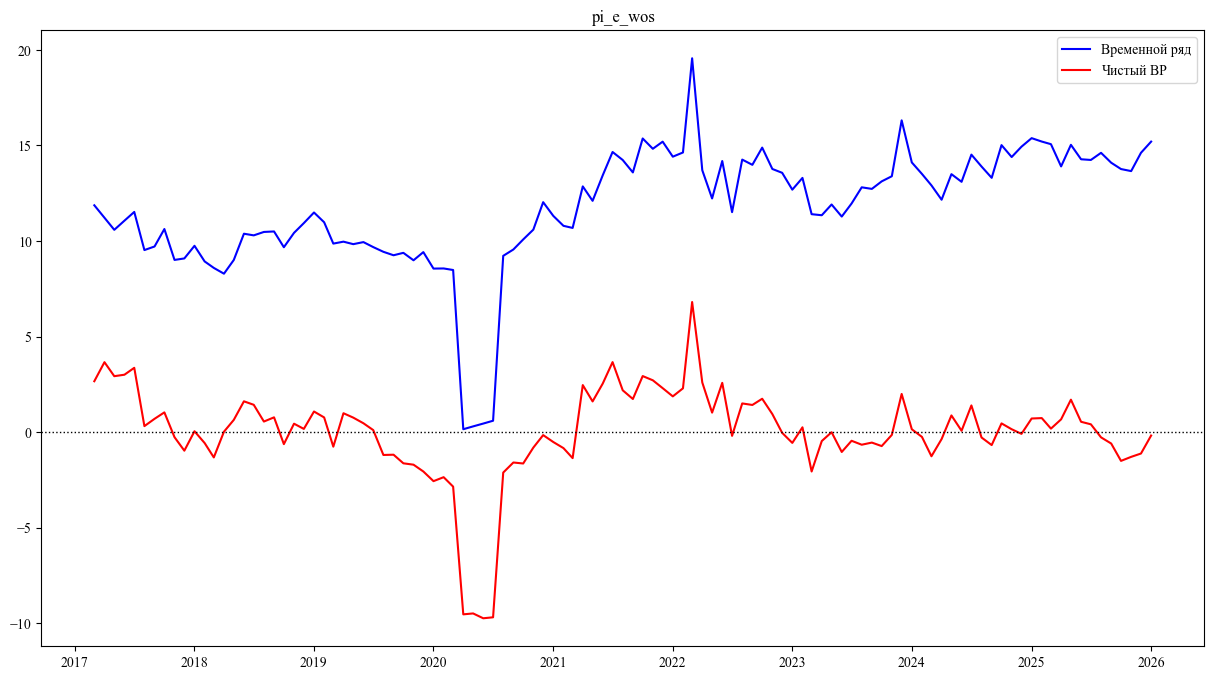

Исходный ряд pi_e_wos оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


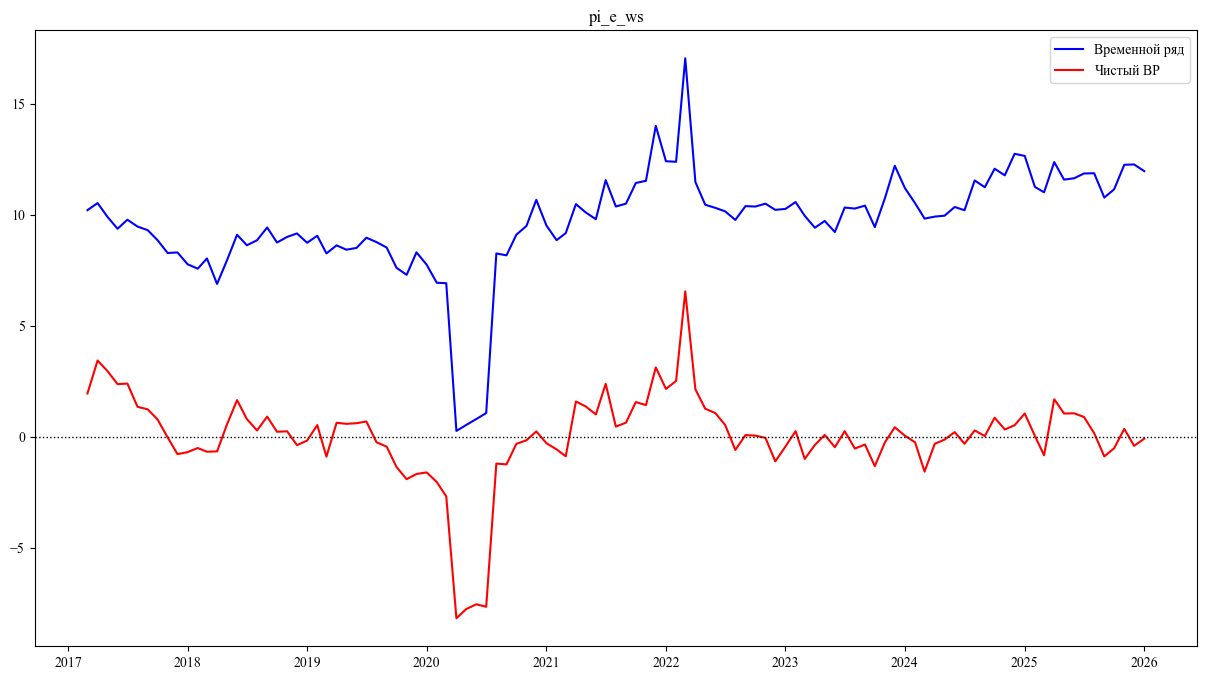

Исходный ряд pi_e_ws оказался стационарным


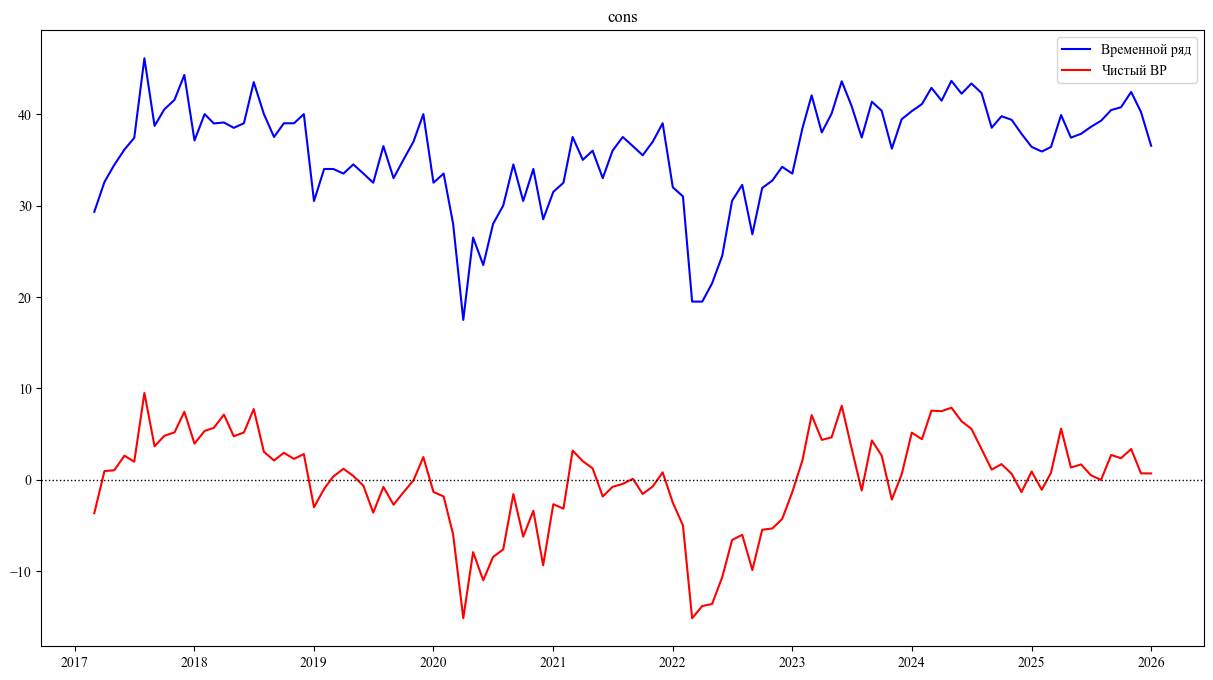

Исходный ряд cons оказался стационарным


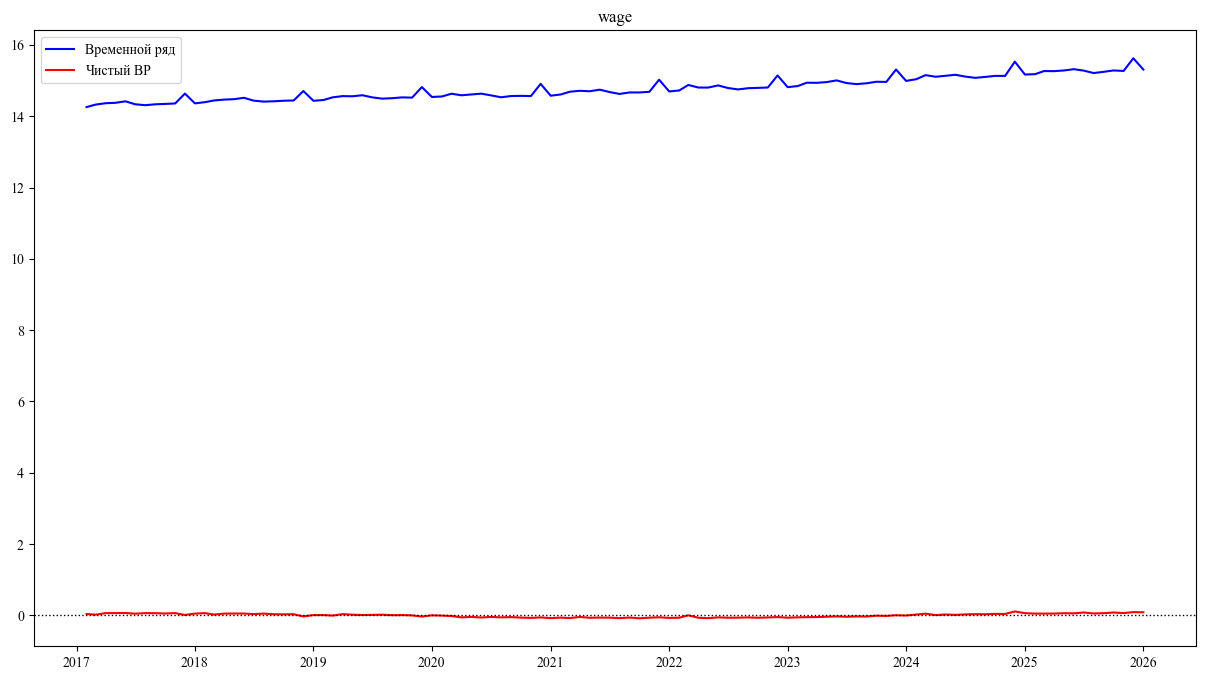

Исходный ряд wage оказался стационарным
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор


In [2]:
lag = 2
var_spec_pie = Clean(monthly_data.loc[(monthly_data.index > dt(2014, 6, 1)) & (monthly_data.index < dt(2026, 2, 1)),
                                   ['pi_e', 'pi_e_wos', 'pi_e_ws', 'cons', 'wage']])
df_pie, data_pie = var_spec_pie.LOS(use_harmonics=False, only_KPSS = True)
endog_names_pie_general = ['wage', 'cons']
endog_names_pie_special = ['pi_e', 'pi_e_ws', 'pi_e_wos']
results = {}
for var in endog_names_pie_special:
    df_endog = data_pie.loc[endog_names_pie_general + [var], :].copy()
    df_endog = df_endog.loc[:,df_endog.columns < dt(2020, 4, 1)].copy()   # K×T

    model = SVAR_KL(
        data=df_endog,
        p=lag,
        layout="KL_KxT",
        time_order="chronological",
        add_const=True,
        u_dict = ['шок доходов', 'шок оптимизма', 'шок ОИ'],
        y_dict = ['Объем фонда зарплаты (логарифм)', 'индекс оптимизма', 'инфляционные ожидания']
    ).fit_ols()
    A_hat = model.A_hat
    p = model.p
    K = model.K
    
    unknown_mask = np.array([False, False, True])  

    known_future = data_pie.loc[endog_names_pie_general, :].copy().loc[:,
                        (data_pie.columns > dt(2020, 3, 1)) & (data_pie.columns < dt(2020, 8, 1))]
    res = []
    horizon = known_future.shape[1]
    counter = 0
    future = pd.DataFrame(columns=known_future.columns)
    for i, b in enumerate(unknown_mask):
        
        if not b:
            future.loc[known_future.index.to_list()[i-counter]] = known_future.iloc[i-counter]
        else:
            counter += 1
            future.loc[var] = np.zeros(horizon)    
    for h in range(horizon):
        if h == 0:
            X = model.Z[:, -1]
            
        else:
            
            X = np.hstack([np.array([1]), future.iloc[:, h-1].to_numpy(), X[1:-(K)]])
        y_hat = (A_hat @ X)[unknown_mask]
        future.loc[unknown_mask, future.columns[h]] = y_hat.item()
    results[var] = future.loc[unknown_mask, :]

for var in results:
    data.loc[var,(data.columns > dt(2020, 3, 1)) & (data.columns < dt(2020, 8, 1))] = results[var].to_numpy()

Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор


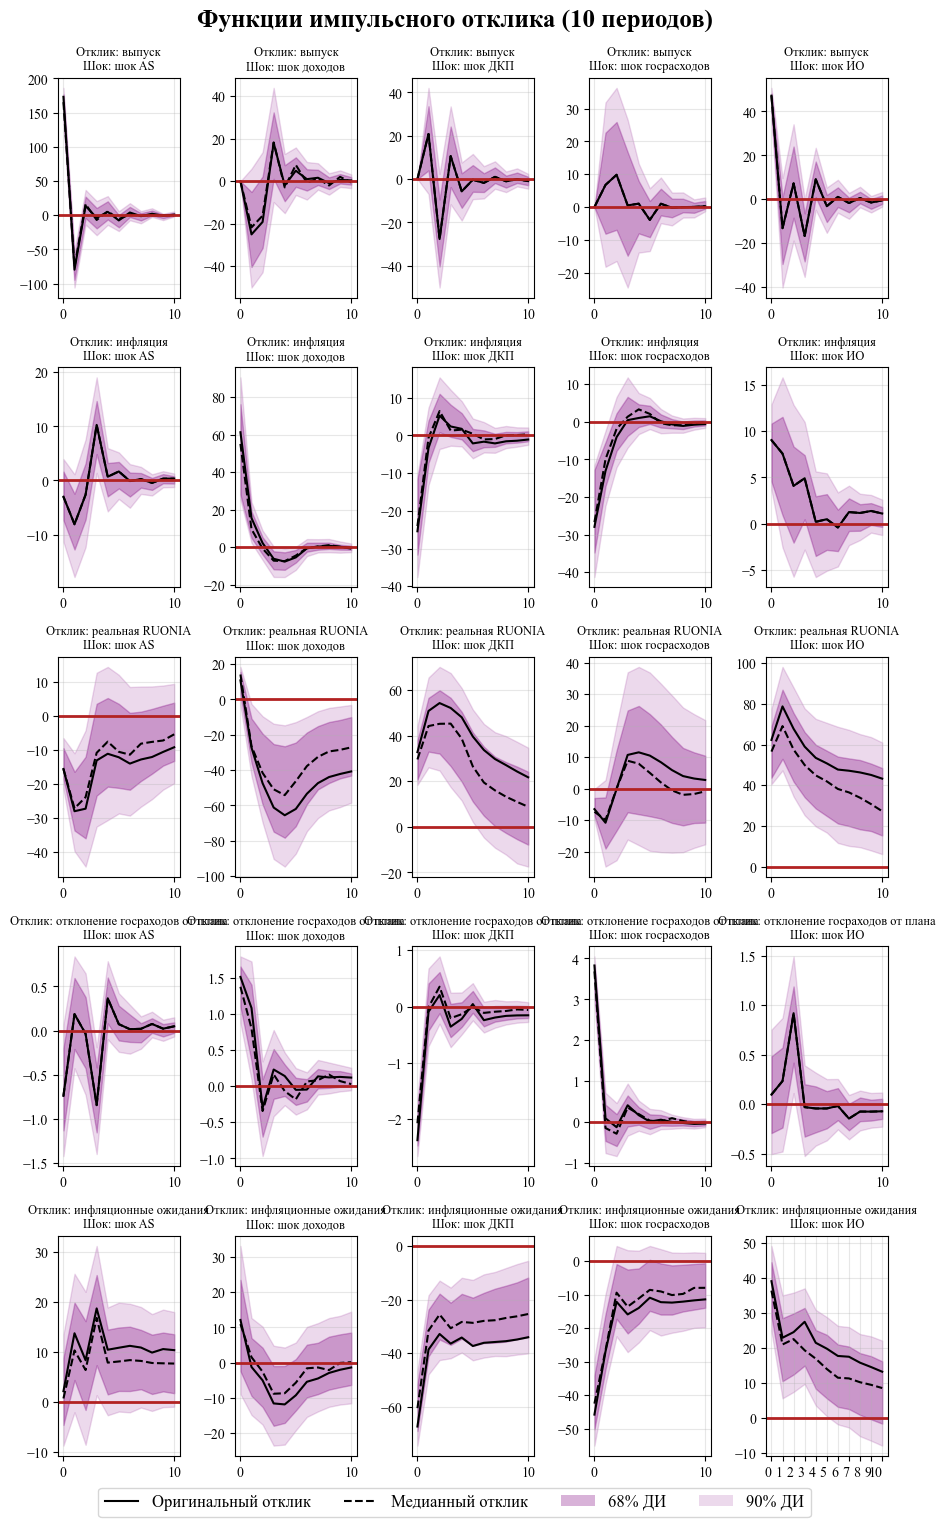

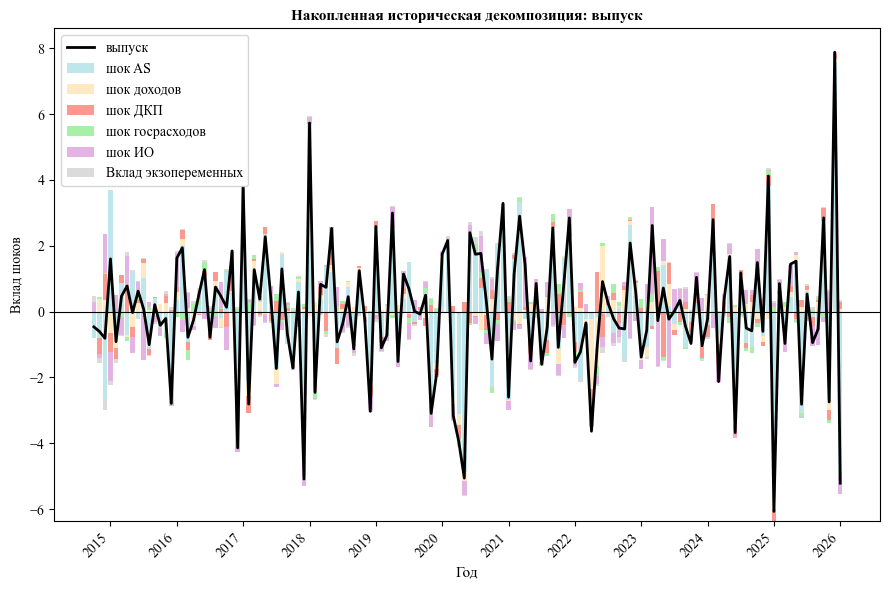

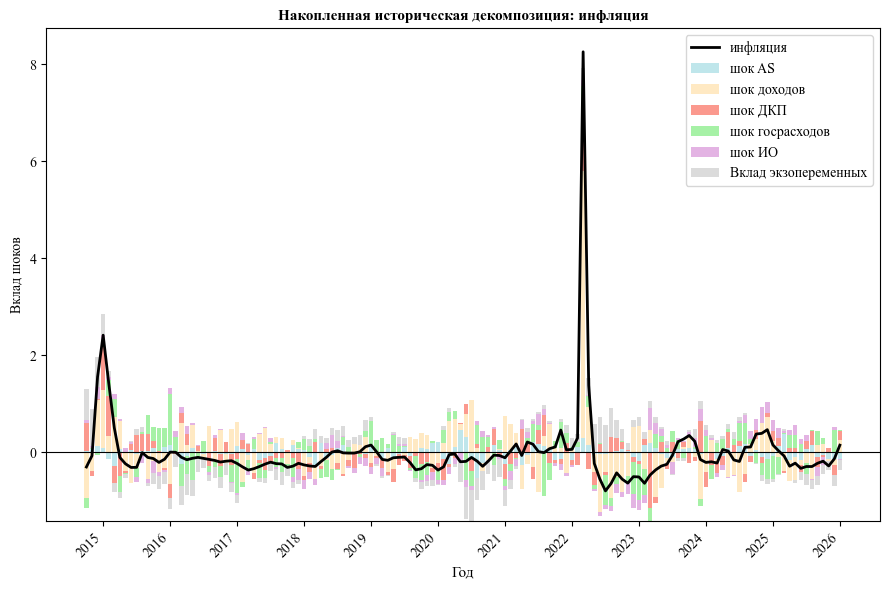

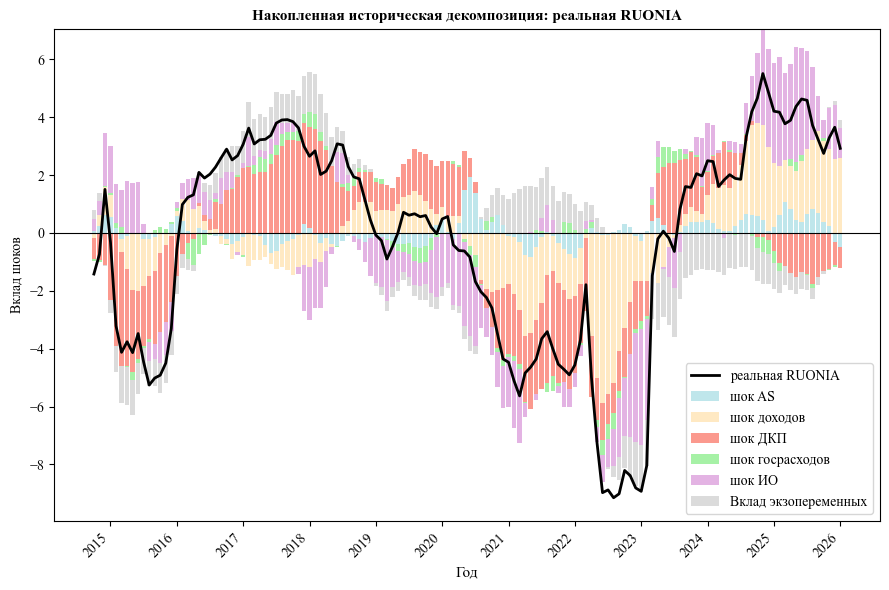

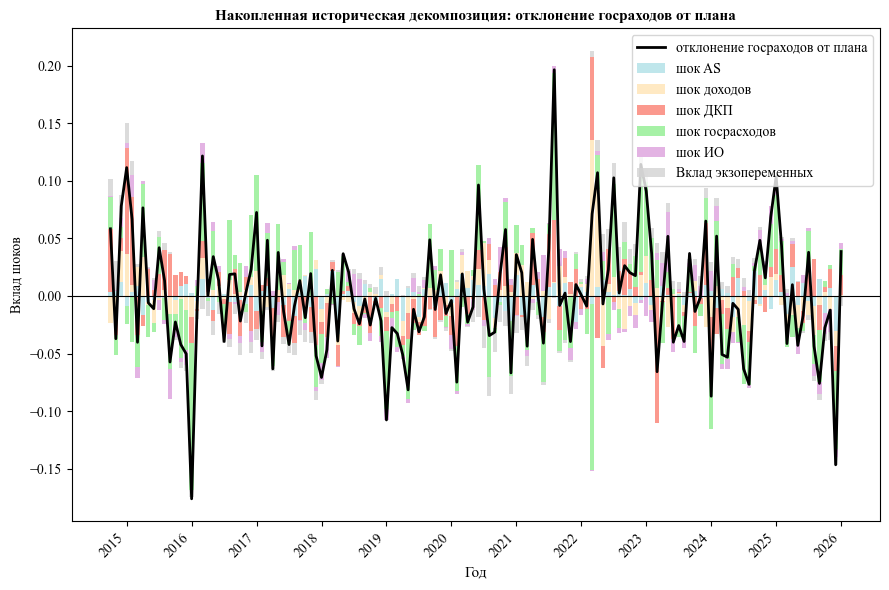

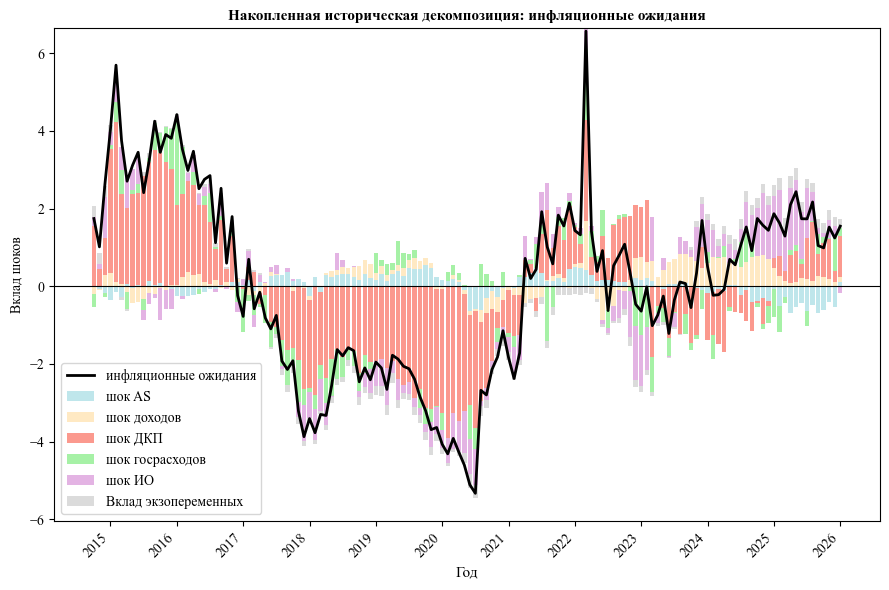

In [3]:
short_run_anchor = [
    (0, 0, 1, 0, 1),
    (0, 0, 2, 0, 1),
    (0, 0, 3, 0, 1),
]
long_run_anchor = [
    (0, 2, 2, 10)
]
short_run_signs = [
    (0, 1, 2, False, 0, 2),
                   (0, 1, 1, True, 0, 1),
                   (0, 2, 2, True, 0, 1),
                   (0, 3, 3, True, 0, 5),
                   (0, 4, 4, True, 0, 1),
                   (0, 0, 0, True, 0, 1),
    (0, 3, 2, False, 0, 1),
    (0, 4, 2, False, 0, 1),


                   ]
long_run_signs = [
    (0, 4, 4, True, 1),

]
#data = pd.read_pickle('data.pkl')
lag = 3

endog_names = ['ipi', 'ru_cpi', 'real_ruonia', 'govspend', 'pi_e']
exog_names  = ['real_brent']

df_endog = data.loc[endog_names, :]   # K×T
df_exog  = data.loc[exog_names, :]    # K_ex×T

model = SVAR_KL(
    data=df_endog,
    p=lag,
    exog=df_exog,              #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    u_dict = ['шок AS', 'шок доходов', 'шок ДКП', 'шок госрасходов', 'шок ИО'],
    y_dict = ['выпуск', 'инфляция', 'реальная RUONIA', 
              'отклонение госраходов от плана', 'инфляционные ожидания']
).fit_ols()

rr = model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 120
irf0 = model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=10,
                     main_color='purple')
hd = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = False,
                                    const_clean = True)

In [4]:
# Структурные шоки для диссертации
U = np.linalg.inv(model.B0inv) @ model.E
pd.DataFrame(U, columns=model.time_index[model.p:], index = list(model.u_dict.keys())).to_excel('data/structural_shocks.xlsx')

In [5]:
# Доля абсолютных вкладов в историческю декомпозицию инфляционных ожиданий
share_hd = hd[0][4].loc[:, [i > dt(2020, 8, 1) for i in hd[0][4].columns.tolist()]].copy()
share_hd.loc['Необъяснено шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
share_hd = share_hd.abs().copy()
share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
share_array = share_hd.sum(axis=1)
share_array.iloc[1:]/share_array.iloc[1:].sum()

шок AS                  0.085596
шок доходов             0.143087
шок ДКП                 0.339844
шок госрасходов         0.134736
шок ИО                  0.217524
Вклад экзопеременных    0.065315
Необъяснено шоками      0.013898
dtype: float64

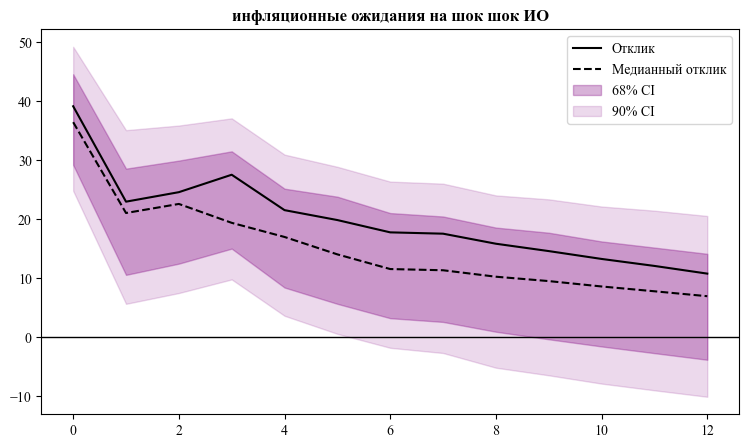

In [6]:
model.plot_single_irf(irf_sims = irf_sims,
                      horizon=12,
                      variable='pi_e',
                      shock = 'шок ИО',
                      ci_color = 'purple',
                      plot_simulations = False)